In [1]:
import numpy as np
from bhjet import RadiationZone, TargetBlackBody
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
erg2eV = 6.242e+11 #1erg in eV
c = 3e10 # cm/s

make a new RadiationZone object like in single_zone_example.ipynb, but this time with strong Compton cooling

In [3]:
distance_kpc = 1e4 # kpc
redshift = 0.001
bulk_momentum = 0# beta*Gamma

rad = RadiationZone(
    magnetic_field=1, # G
    radius=1e17, # cm
    height=1e15, # cm, irrelevant when geometry=sphere
    geometry="sphere",
    bulk_momentum=bulk_momentum, # beta*Gamma
    theta_obs=20, # degree
    distance=distance_kpc, # kpc
    redshift=redshift, 
    electron_number_density=1e5, # 1/cm³
    proton_number_density=1, # 1/cm³
    electron_temperature=1e3, # keV
    proton_temperature=1e3, # keV
    fraction_nonthermal_electrons=0.1, 
    fraction_nonthermal_protons=0.1, 
    factor_break_electrons=1, 
    factor_break_protons=1, 
    factor_max_energy_electrons=1, 
    factor_max_energy_protons=1, 
    index_injected_electrons=2, 
    index_injected_protons=2, 
    include_counterjet=True, 
    force_compton_calculation=True, 
    compton_switch=False, # only used when force_compton_calculation=True
    compton_threshold=1e-50, # only used when force_compton_calculation=False
    profile_time=True,
    verbosity_level=1
)

Let's add a black body but make it's density small compared to the synchrotron emission

In [4]:
bb1 = TargetBlackBody(
    name="bb1", 
    distance=distance_kpc,
    redshift=redshift,
    luminosity=1e41, # erg/(cm²s)
    temperature=1e-3, # keV
    energy_density=1e-2) # erg/cm³

Text(0, 0.5, 'energy density [erg/cm³]')

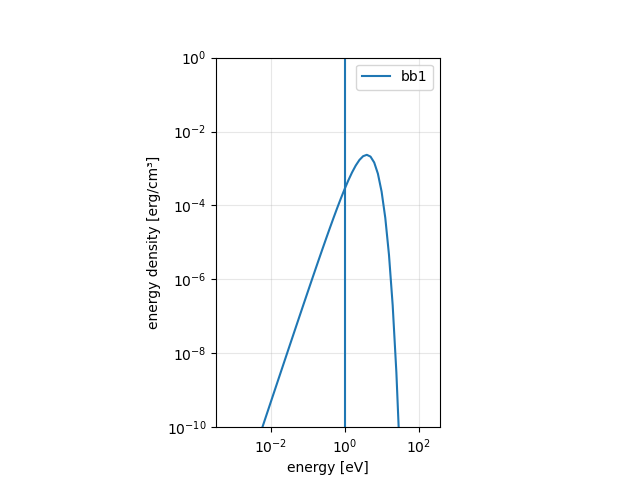

In [5]:
figbb, axbb = plt.subplots()
Ebb1_erg, E2dn_dE_bb1 = bb1.get_target_energy_grid_and_density(
    z=0, # does not matter for a black body
    bulk_momentum=rad.bulk_momentum, # for boosting
    theta_obs=rad.theta_obs,  # for boosting
    min_energy=1e-15, max_energy=1)  # erg, just to define the energy range
axbb.loglog(Ebb1_erg * erg2eV, E2dn_dE_bb1, label=bb1.name)
axbb.axvline(bb1.temperature * 1e3)
axbb.legend()
axbb.set_aspect("equal")
axbb.grid(alpha=0.3)
axbb.set_ylim(1e-10, 1)
axbb.set_xlabel("energy [eV]")
axbb.set_ylabel("energy density [erg/cm³]")

In [6]:
# temperature in keV, energy_density in erg/cm³
rad.add_target_photon_field(Ebb1_erg, E2dn_dE_bb1, bb1.name)
rad.compute_particles()
energy_grid_flux = np.logspace(-6, 16, 300) / erg2eV
rad.compute_radiation(energy_grid_flux)

We see that the synchrotron photons dominated the IC cooling, so will feedback into the electron spectra

(1e-15, 1.0)

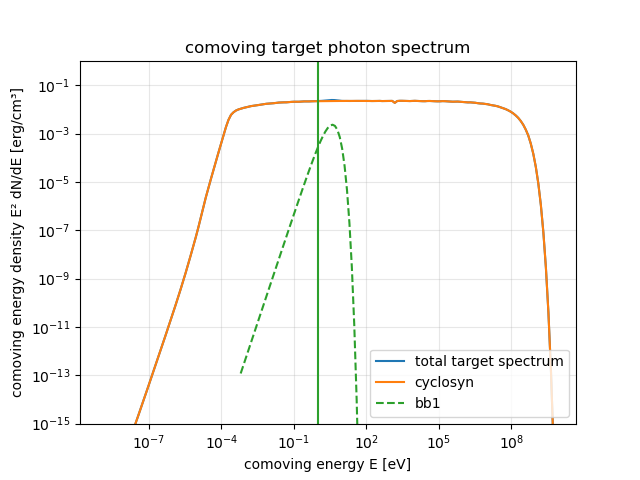

In [7]:
figpt, axpt = plt.subplots()

energy = rad.get_total_photon_target_energy()
axpt.loglog(energy*erg2eV, rad.get_total_photon_target_energy_density(), label="total target spectrum")
axpt.loglog(rad.get_photon_target_energy("cyclosynchrotron")*erg2eV, rad.get_photon_target_energy_density("cyclosynchrotron"), label="cyclosyn")
axpt.loglog(Ebb1_erg * erg2eV, E2dn_dE_bb1, label=bb1.name, ls="--")
axpt.axvline(bb1.temperature * 1e3, c="tab:green")
axpt.legend()
axpt.set_xlabel("comoving energy E [eV]")
axpt.set_ylabel("comoving energy density E² dN/dE [erg/cm³]")
axpt.grid(alpha=0.3)
axpt.set_aspect("equal")
axpt.set_title("comoving target photon spectrum")
axpt.set_ylim(1e-15, 1e0)

In [8]:
mom = np.logspace(-8, 8, 160) /c

(1e-05, 30000000000.0)

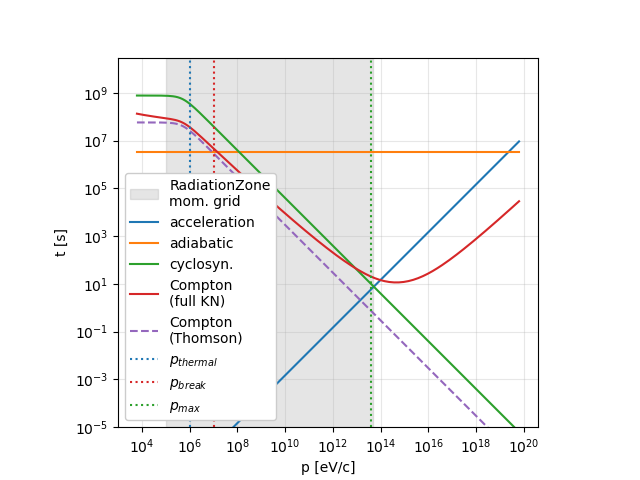

In [9]:
fig, axt = plt.subplots()
mom_grid = rad.get_electron_momentum_grid()
axt.axvspan(mom_grid[0]*erg2eV*c, mom_grid[-1]*erg2eV*c, color="grey", alpha=0.2, label="RadiationZone\nmom. grid")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_acceleration(mom), c="tab:blue", label="acceleration")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_adiabatic(mom), c="tab:orange", label="adiabatic")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_cyclosyn(mom), c="tab:green", label="cyclosyn.")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_compton(mom), c="tab:red", label="Compton\n(full KN)")
axt.loglog(mom*erg2eV*c, rad.get_timescale_electron_compton_thomson(mom), c="tab:purple", label="Compton\n(Thomson)", ls="--")
axt.axvline(rad.electron_temperature*1e3, ls=":", label=r"$p_{thermal}$")
axt.axvline(rad.get_electron_break_momentum()*erg2eV*c, ls=":", c="tab:red", label=r"$p_{break}$")
axt.axvline(rad.get_electron_max_momentum()*erg2eV*c,ls=":", c="tab:green", label=r"$p_{max}$")
axt.legend(framealpha=1)
axt.set_xlabel("p [eV/c]")
axt.set_ylabel("t [s]")
axt.grid(alpha=0.3)
axt.set_aspect("equal")
axt.set_ylim(1e-5, 3e10)


Let's store the particles after round 1, and solve again, now with the synchrotron spectra

In [10]:
num0 =rad.get_electron_momentum_number_density()
t_IC0 = rad.get_timescale_electron_compton_thomson(mom)
t_ICfull0 = rad.get_timescale_electron_compton(mom)
flux_tot0 = rad.get_observed_photon_flux_total()
rad.compute_particles(reset_photon_targets=False)
rad.compton_switch = True
rad.compute_radiation(energy_grid_flux)

Text(0.5, 1.0, 'comoving electron spectrum')

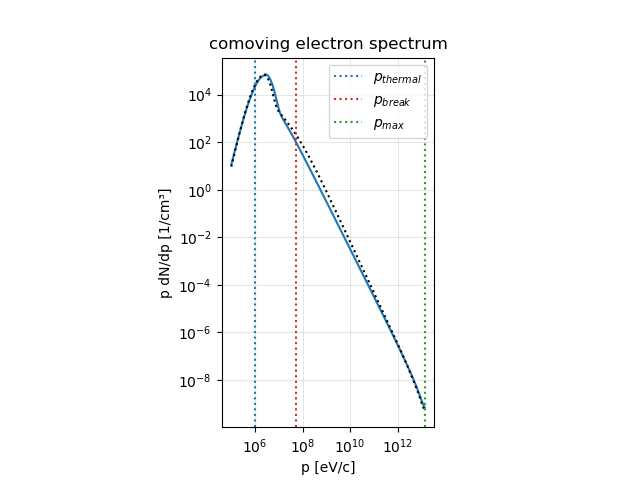

In [11]:
fig, ax = plt.subplots()

mom = rad.get_electron_momentum_grid()
ax.loglog(mom*erg2eV*c, rad.get_electron_momentum_number_density())
ax.loglog(mom*erg2eV*c, num0, ls=":", c="k")
ax.axvline(rad.electron_temperature*1e3, ls=":", label=r"$p_{thermal}$")
ax.axvline(rad.get_electron_break_momentum()*erg2eV*c, ls=":", c="tab:red", label=r"$p_{break}$")
ax.axvline(rad.get_electron_max_momentum()*erg2eV*c,ls=":", c="tab:green", label=r"$p_{max}$")
ax.legend()
ax.set_xlabel("p [eV/c]")
ax.set_ylabel("p dN/dp [1/cm³]")
ax.grid(alpha=0.3)
ax.set_aspect("equal")
ax.set_title("comoving electron spectrum")


The final photon emission can be read out as number flux, ie. EdN/dEdtdA, for the total emission and split up into components.

(1e-20, 1.0)

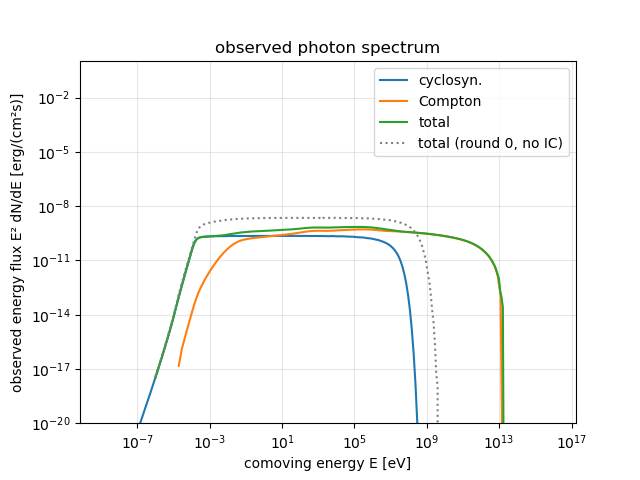

In [12]:
fig, axp = plt.subplots()

energy_syn = rad.get_observed_photon_energy_grid_electron_cyclosyn()
axp.loglog(energy_syn*erg2eV,energy_syn * rad.get_observed_photon_flux_electron_cyclosyn(), label="cyclosyn.")
energy_com = rad.get_observed_photon_energy_grid_electron_compton()
axp.loglog(energy_com*erg2eV,energy_com * rad.get_observed_photon_flux_electron_compton(), label="Compton")
energy_tot = rad.get_observed_photon_energy_grid_total()
axp.loglog(energy_tot*erg2eV,energy_tot * rad.get_observed_photon_flux_total(), label="total")
axp.loglog(energy_tot*erg2eV,energy_tot * flux_tot0, label="total (round 0, no IC)", ls=":", c="grey")

mainLF = rad.get_electron_gamma_grid()[np.argmax(rad.get_electron_momentum_grid()*rad.get_electron_momentum_number_density())]
# black bodies get scattered to energies avLF^2 * E_target
# E_target ~ 4 * kT * doppler, with the 4 accounting for the difference between max and average
# axp.axvline(mainLF**2 * 4 * rad.get_target_black_body_temperature("bb1")*1e3 * rad.doppler_factor_bulk, color="tab:orange", ls=":")
# axp.axvline(mainLF**2 * 4 * rad.get_target_black_body_temperature("bb2")*1e3 * rad.doppler_factor_bulk, color="tab:green", ls=":")
axp.legend()
axp.set_xlabel("comoving energy E [eV]")
axp.set_ylabel("observed energy flux E² dN/dE [erg/(cm²s)]")
axp.grid(alpha=0.3)
axp.set_aspect("equal")
axp.set_title("observed photon spectrum")
axp.set_ylim(1e-20, 1e0)

In [13]:
times = rad.get_computation_times()
print(f"Particle computation took {times[0]*1e-6:.1e} ms")
print(f"Cyclosyn. computation took {times[1]*1e-6:.1e} ms")
print(f"Compton computation took {times[2]*1e-6:.1e} ms")

Particle computation took 8.8e-02 ms
Cyclosyn. computation took 1.3e+00 ms
Compton computation took 2.7e+01 ms
